# FITE Classification Challenge

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

في هذا المشروع بنينا نظام تصنيف متعدد الكلاسات لبيانات مجهولة الأعمدة. كل صف يحتوي على 21 خاصية مرمزة من `f1` إلى `f21`، والمطلوب توقع قيمة `target` في ملف الاختبار.

منهجية الحل اعتمدت على ثلاث أفكار رئيسية: فهم الداتا إحصائيا، اختيار الموديلات بناء على تحقق داخلي موثوق، ثم توثيق التجارب والمخرجات حتى يكون الحل قابلا للإعادة.

اعتمدنا على `StratifiedKFold` و`Macro F1` لأن توزيع الكلاسات غير متوازن. نتيجة Kaggle العامة استخدمت كفحص خارجي فقط، بينما قرار اختيار الموديل بني على نتائج التحقق الداخلي.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 1. تجهيز المكتبات والإعدادات

نبدأ بتجهيز المكتبات والثوابت المستخدمة في كامل المشروع. وضعنا `RANDOM_STATE = 42` حتى تكون تقسيمات التحقق والتدريب قابلة للتكرار. كما حددنا أسماء ملفات الداتا والمخرجات في مكان واحد حتى يبقى تشغيل النوتبوك والملف البرمجي واضحا.

هذه الخلية لا تدرب أي نموذج؛ دورها تجهيز البيئة وتعريف المسارات والمكتبات التي ستستخدمها الخلايا التالية.

</div>

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
ARTIFACT_DIR = Path("classification_artifacts")

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 2. قراءة الداتا وفحص الشكل العام

قرأنا ملفات `train_data.csv` و`test_data.csv` و`sample_submission.csv`. بيانات التدريب تحتوي على 3200 صف و23 عمودا: عمود `ID`، و21 خاصية، وعمود الهدف `target`. بيانات الاختبار تحتوي على 3200 صف و22 عمودا لأنها لا تحتوي على `target`.

فحص الأعمدة أكد أن خصائص التدريب والاختبار متطابقة، وفحص القيم المفقودة أكد أن الداتا لا تحتوي على missing values. لذلك لم نحتج إلى imputation، وركزنا على التقييم، هندسة خصائص عامة، واختيار الموديل.

</div>

In [2]:
train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)
sample_submission = pd.read_csv(SAMPLE_FILE)

ID_COL = "ID"
TARGET_COL = "target"
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

assert TARGET_COL in train.columns
assert TARGET_COL not in test.columns
assert feature_cols == [c for c in test.columns if c != ID_COL]
assert sample_submission[ID_COL].tolist() == test[ID_COL].tolist()

basic_checks = pd.DataFrame({
    "الفحص": [
        "شكل train", "شكل test", "عدد الخصائص", "القيم المفقودة في train", "القيم المفقودة في test",
        "ID فريد في train", "ID فريد في test", "صفوف مكررة حسب الخصائص في train", "صفوف مكررة حسب الخصائص في test"
    ],
    "القيمة": [
        train.shape, test.shape, len(feature_cols), int(train.isna().sum().sum()), int(test.isna().sum().sum()),
        bool(train[ID_COL].is_unique), bool(test[ID_COL].is_unique), int(train[feature_cols].duplicated().sum()), int(test[feature_cols].duplicated().sum())
    ]
})

display(basic_checks)
display(train.head())
display(test.head())

,الفحص,القيمة
0,شكل train,"(3200, 23)"
1,شكل test,"(3200, 22)"
2,عدد الخصائص,21
3,القيم المفقودة في train,0
4,القيم المفقودة في test,0
5,ID فريد في train,True
6,ID فريد في test,True
7,صفوف مكررة حسب الخصائص في train,57
8,صفوف مكررة حسب الخصائص في test,7


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,0.00088,0,0,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,0.00510,0,0,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,0.00189,0,0,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,0.00020,0,1,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,0.00720,0,0,0,0.10400,0,0,0,0,0,0.116,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.57,0.023,0,1,0,0,0,0,0.115,0.00600,0,1,1,0.11954,0,0,0,0,0,0.096,0
1,10001,0.54,0.013,1,0,0,0,0,0,0.102,0.00085,0,0,0,0.11300,0,0,0,0,0,0.091,0
2,10002,0.56,0.019,0,1,0,0,0,0,0.096,0.00097,0,0,0,0.10300,0,0,0,0,0,0.093,0
3,10003,0.26,0.023,1,0,0,0,0,0,0.096,0.00110,0,0,0,0.12300,0,0,0,0,0,0.078,0
4,10004,0.60,0.023,0,1,1,0,0,0,0.155,0.00004,0,1,0,0.22100,0,0,0,1,0,0.070,0


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة فحص الداتا

الداتا جاهزة من ناحية البنية: نفس الخصائص موجودة في train وtest، ولا توجد قيم مفقودة. هذا يجعل مصدر الصعوبة الأساسي ليس تنظيف missing values، بل التعامل مع عدم توازن الكلاسات واختيار نموذج يعمم جيدا على بيانات الاختبار.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 3. توزيع الكلاسات واختيار معيار التقييم

توزيع الهدف غير متوازن بشكل واضح: `class3` تمثل 2916 صفا من أصل 3200، أي حوالي 91.12%. بالمقابل `class2` تمثل 5.97%، و`class1` تمثل 2.91% فقط.

لهذا السبب لا تكفي Accuracy وحدها. النموذج الذي يميل للكلاس الأكبر قد يحصل على Accuracy عالية، لكنه لا يكون جيدا فعليا للكلاسات الصغيرة. لذلك استخدمنا `Macro F1` لأنه يعطي وزنا متقاربا لكل كلاس، ويكشف أداء النموذج على الكلاسات القليلة.

</div>

,count,percentage
target,,
class1,93,2.906
class2,191,5.969
class3,2916,91.125


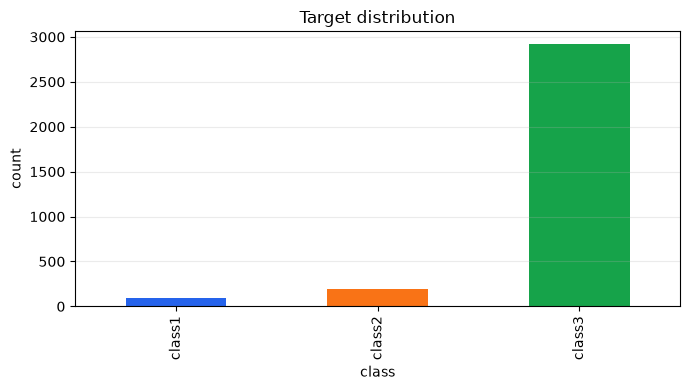

In [3]:
target_counts = train[TARGET_COL].value_counts().sort_index()
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": (target_counts / len(train) * 100).round(3)
})
display(target_distribution)

fig, ax = plt.subplots(figsize=(7, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Target distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة توزيع الهدف

المشكلة الأساسية في الهدف هي عدم التوازن. لذلك استخدمنا `StratifiedKFold` للحفاظ على نسب الكلاسات داخل كل fold، واستخدمنا `class_weight='balanced'` في النماذج التي تدعمه. معيار `Macro F1` أصبح معيار المقارنة الرئيسي بين النماذج.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 4. فهم أنواع الخصائص

بما أن أسماء الخصائص مجهولة، تعاملنا معها حسب سلوكها الإحصائي. وجدنا 15 خاصية ثنائية قيمها 0/1، و6 خصائص مستمرة هي `f1`, `f2`, `f9`, `f10`, `f14`, `f20`.

هذا التقسيم استخدم لاحقا في هندسة الخصائص: جمعنا معلومات عن الخصائص الثنائية، وأنشأنا تفاعلات عامة بين الخصائص المستمرة بدون افتراض أي معنى خارجي لها.

</div>

In [4]:
binary_features = []
continuous_features = []
for c in feature_cols:
    train_values = set(train[c].dropna().unique())
    test_values = set(test[c].dropna().unique())
    if train_values.issubset({0, 1, 0.0, 1.0}) and test_values.issubset({0, 1, 0.0, 1.0}):
        binary_features.append(c)
    else:
        continuous_features.append(c)

feature_type_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "train_nunique": [train[c].nunique() for c in feature_cols],
    "test_nunique": [test[c].nunique() for c in feature_cols],
    "train_mean": [train[c].mean() for c in feature_cols],
    "test_mean": [test[c].mean() for c in feature_cols],
})
feature_type_df["abs_mean_diff"] = (feature_type_df["train_mean"] - feature_type_df["test_mean"]).abs()

display(feature_type_df.sort_values(["type", "abs_mean_diff"], ascending=[True, False]))
print("Binary:", binary_features)
print("Continuous:", continuous_features)

,feature,type,train_nunique,test_nunique,train_mean,test_mean,abs_mean_diff
17,f18,binary,2,2,0.059375,0.077188,0.017813
11,f12,binary,2,2,0.122813,0.139375,0.016562
6,f7,binary,2,2,0.005000,0.020938,0.015938
12,f13,binary,2,2,0.061875,0.069687,0.007812
7,f8,binary,2,2,0.012188,0.018437,0.006250
20,f21,binary,2,2,0.013437,0.007500,0.005938
4,f5,binary,2,2,0.014687,0.019062,0.004375
14,f15,binary,2,2,0.011250,0.014063,0.002813
2,f3,binary,2,2,0.045000,0.046562,0.001563
5,f6,binary,2,2,0.038750,0.037187,0.001563


Binary: ['f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f11', 'f12', 'f13', 'f15', 'f16', 'f17', 'f18', 'f19', 'f21']
Continuous: ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة تحليل أنواع الخصائص

الداتا ليست نصية ولا تحتوي categorical strings؛ هي رقمية بالكامل. وجود عدد كبير من الخصائص الثنائية مع عدة خصائص مستمرة يجعل نماذج الأشجار والـ boosting مناسبة، لأنها تلتقط الشروط والتفاعلات بين الخصائص بدون الحاجة إلى scaling قوي في أغلب الحالات.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 5. مقارنة توزيع Train و Test

قارننا متوسط كل خاصية بين train وtest للتأكد من أن بيانات الاختبار ليست مختلفة جذريا عن بيانات التدريب. أكبر فروقات ظهرت في `f18`, `f12`, `f7`, `f1`, و`f13`، لكنها بقيت صغيرة نسبيا؛ أكبر فرق كان حوالي 0.0178.

هذا الفحص لا يستخدم أي target من الاختبار، ولا يغير التنبؤات مباشرة. دوره فقط تقييم مدى تشابه التوزيع بين train وtest.

</div>

,feature,type,train_mean,test_mean,abs_mean_diff
17,f18,binary,0.059375,0.077188,0.017813
11,f12,binary,0.122813,0.139375,0.016562
6,f7,binary,0.005000,0.020938,0.015938
0,f1,continuous,0.516861,0.526824,0.009963
12,f13,binary,0.061875,0.069687,0.007812
13,f14,continuous,0.109880,0.116732,0.006852
7,f8,binary,0.012188,0.018437,0.006250
20,f21,binary,0.013437,0.007500,0.005938
4,f5,binary,0.014687,0.019062,0.004375
8,f9,continuous,0.107968,0.110992,0.003023


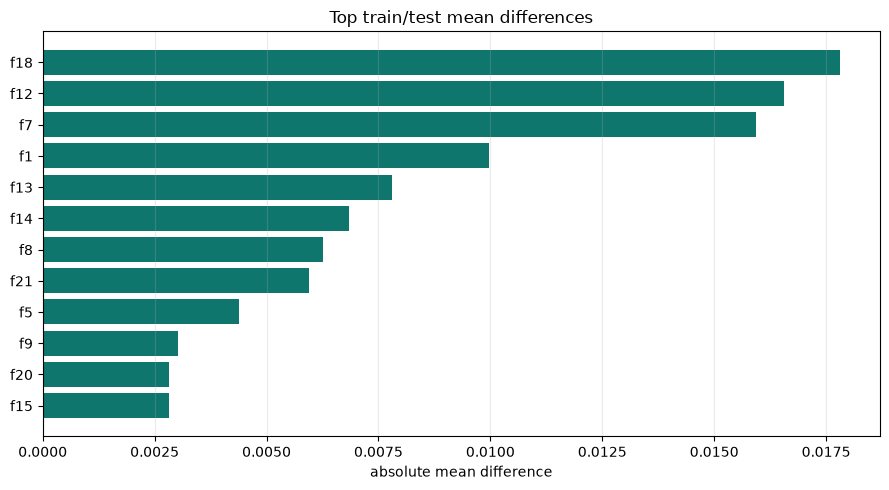

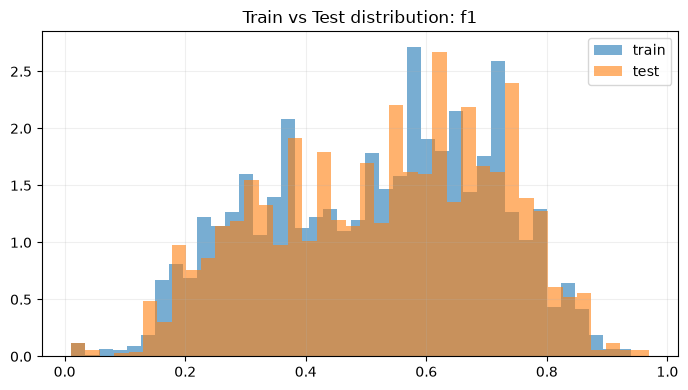

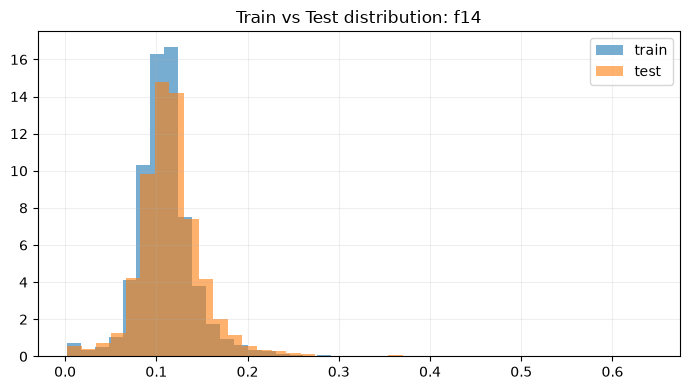

In [5]:
drift_df = feature_type_df.sort_values("abs_mean_diff", ascending=False)
display(drift_df[["feature", "type", "train_mean", "test_mean", "abs_mean_diff"]].head(12))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = drift_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["abs_mean_diff"], color="#0f766e")
ax.set_title("Top train/test mean differences")
ax.set_xlabel("absolute mean difference")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

for c in [x for x in drift_df["feature"].head(6) if x in continuous_features]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[c], bins=40, alpha=0.6, density=True, label="train")
    ax.hist(test[c], bins=40, alpha=0.6, density=True, label="test")
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة مقارنة Train و Test

توزيع الخصائص في train وtest متقارب إجمالا. هذا يدعم الاعتماد على التحقق الداخلي، لكنه لا يلغي الحاجة إلى الحذر لأن جزءا من الاختبار يبقى غير ظاهر في نتيجة Public. لذلك اعتمدنا على ثبات التحقق الداخلي وليس على نتيجة رفع واحدة فقط.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 6. أهمية الخصائص من بيانات التدريب

استخدمنا `Mutual Information` و`ANOVA F-score` على بيانات التدريب فقط لفهم الخصائص الأكثر ارتباطا بالهدف. أقوى الإشارات ظهرت في `f10`, `f14`, `f9`, و`f2`.

هذه النتيجة فسرت لماذا أضافت هندسة الخصائص تفاعلات بين هذه الأعمدة المستمرة، مثل الضرب والطرح والنسب. كل ذلك تم من train فقط وبدون استخدام أي label من test.

</div>

,feature,type,mutual_information,anova_f_score,anova_pvalue
9,f10,continuous,0.281781,991.761826,0.000000e+00
13,f14,continuous,0.137953,331.484714,1.502435e-131
8,f9,continuous,0.108202,283.363477,5.076408e-114
1,f2,continuous,0.092057,117.512854,5.669935e-50
11,f12,binary,0.020573,14.852188,3.798027e-07
12,f13,binary,0.012737,14.289268,6.634724e-07
0,f1,continuous,0.012244,0.572002,5.644521e-01
16,f17,binary,0.009627,1.553742,2.116149e-01
19,f20,continuous,0.009546,3.082477,4.598183e-02
15,f16,binary,0.004152,1.177318,3.082374e-01


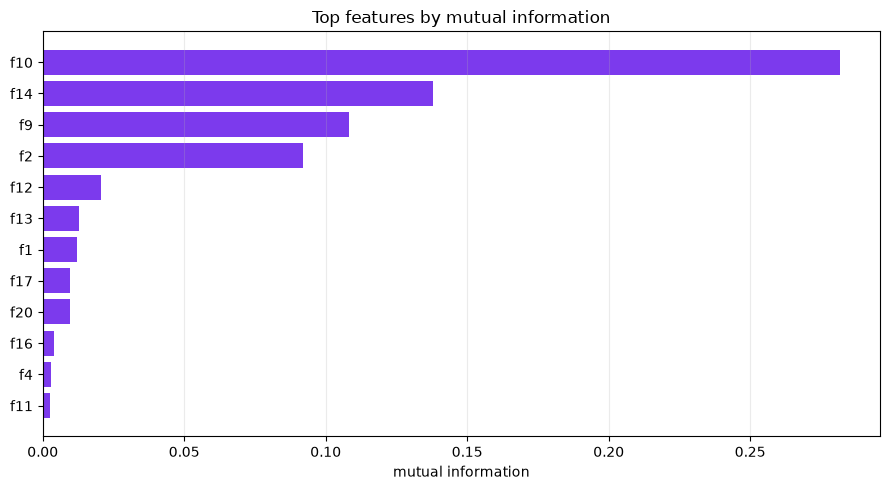

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(train[TARGET_COL])
class_names = list(le.classes_)

mi_scores = mutual_info_classif(train[feature_cols], y_encoded, random_state=RANDOM_STATE)
f_scores, f_pvalues = f_classif(train[feature_cols], y_encoded)
feature_score_df = pd.DataFrame({
    "feature": feature_cols,
    "type": ["binary" if c in binary_features else "continuous" for c in feature_cols],
    "mutual_information": mi_scores,
    "anova_f_score": f_scores,
    "anova_pvalue": f_pvalues,
}).sort_values("mutual_information", ascending=False)

display(feature_score_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = feature_score_df.head(12).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_information"], color="#7c3aed")
ax.set_title("Top features by mutual information")
ax.set_xlabel("mutual information")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة تحليل أهمية الخصائص

الخصائص المستمرة الأربع `f10`, `f14`, `f9`, و`f2` تحمل جزءا كبيرا من الإشارة المفيدة. لذلك لم نعتمد فقط على الخصائص الأصلية، بل أضفنا علاقات عامة بينها. هذا رفع قدرة النماذج على التقاط أنماط غير خطية مع الحفاظ على منهجية عامة وغير مبنية على معنى خارجي للأعمدة.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 7. بناء منهجية الحل

بعد الفحص الأولي، بنينا الحل على مراحل واضحة. بدأنا بنماذج بسيطة للتأكد من وجود إشارة قابلة للتعلم، ثم انتقلنا إلى نماذج أقوى تعتمد على الأشجار والـ boosting. بعد ذلك استخدمنا دمج احتمالات النماذج لأن أكثر من نموذج أعطى أداء قويا لكن بأخطاء مختلفة قليلا.

كل خطوة بقيت مرتبطة بنتيجة تحقق داخلية: النموذج يدخل أو يخرج بناء على `Macro F1`, `Balanced Accuracy`, ونتائج الـ confusion matrix.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 8. تشغيل الـ Pipeline النهائي داخل النوتبوك

هذه النسخة من النوتبوك مستقلة بالكامل. الكود التدريبي موجود هنا مقسما إلى خلايا واضحة، والملف `classification_pipeline.py` يحتوي النسخة البرمجية المستقلة من نفس المنهجية.

الـ pipeline ينفذ المراحل التالية: بناء الخصائص، تدريب عدة نماذج، تقييمها باستخدام `StratifiedKFold`, تسجيل النتائج في MLflow، توثيق النماذج البسيطة، فحص ثبات النتائج عبر أكثر من split، بناء ensemble، ثم توليد `submission.csv`.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.1 إعدادات الـ Pipeline والاستيرادات

هذه الخلية تحتوي الاستيرادات والثوابت المستخدمة في التدريب. وضعها داخل النوتبوك يجعل الملف مستقلا ولا يحتاج لاستدعاء ملف خارجي حتى يعمل.

</div>

In [7]:
"""Clean, reproducible pipeline for the FITE Classification Challenge.

What this script does:
- Reads train_data.csv, test_data.csv, sample_submission.csv.
- Performs train-only feature engineering through a sklearn Transformer.
- Evaluates several models with StratifiedKFold validation.
- Logs all experiments to MLflow when available, otherwise to a CSV fallback.
- Builds a probability ensemble from out-of-fold validation results.
- Saves exactly one submission file: submission.csv.

Academic integrity:
- No true_values.csv usage.
- No test labels.
- No leaderboard probing.
- No row-specific overrides.
"""

from __future__ import annotations

import json
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")


RANDOM_STATE = 42
N_SPLITS = 5
USE_REFERENCE_ENSEMBLE_CANDIDATE = True
REFERENCE_ENSEMBLE_F1_TOLERANCE = 0.0011
TRAIN_FILE = "train_data.csv"
TEST_FILE = "test_data.csv"
SAMPLE_FILE = "sample_submission.csv"
OUTPUT_FILE = "submission.csv"
EXPERIMENT_LOG_FILE = "classification_experiment_log.csv"
ARTIFACT_DIR = Path("classification_artifacts")
ROBUST_VALIDATION_SEEDS = [7, 42, 123]


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.2 تثبيت العشوائية و Feature Engineering العام

هنا نثبت الـ seeds ونبني Transformer عام للـ feature engineering. بما أن الأعمدة مجهولة، التحويلات هنا حيادية: تفاعلات بين الأعمدة المستمرة، مؤشرات outliers، وعدّاد للخصائص الثنائية.

</div>

In [8]:
def set_all_seeds(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


class ClassificationFeatureBuilder(BaseEstimator, TransformerMixin):
    """Train-only generic feature engineering for anonymized tabular data.

    Since feature meanings are hidden, the transformations are intentionally
    domain-neutral: interactions among continuous features, binary counts, rare
    binary counts, and train-quantile outlier indicators.
    """

    def __init__(self, outlier_quantiles: tuple[float, float] = (0.01, 0.99), rare_threshold: float = 0.02):
        self.outlier_quantiles = outlier_quantiles
        self.rare_threshold = rare_threshold

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)

        q_low, q_high = self.outlier_quantiles
        self.low_quantiles_ = X[self.cont_cols_].quantile(q_low).to_dict()
        self.high_quantiles_ = X[self.cont_cols_].quantile(q_high).to_dict()
        self.rare_binary_cols_ = [col for col in self.binary_cols_ if float(X[col].mean()) < self.rare_threshold]
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()

        eps = 1e-6
        for col in self.cont_cols_:
            out[f"{col}_sq"] = X[col] ** 2
            out[f"{col}_sqrt"] = np.sqrt(np.clip(X[col], 0, None))
            out[f"{col}_below_q01"] = (X[col] < self.low_quantiles_[col]).astype(int)
            out[f"{col}_above_q99"] = (X[col] > self.high_quantiles_[col]).astype(int)

        # Generic pairwise interactions for continuous variables.
        for i, a in enumerate(self.cont_cols_):
            for b in self.cont_cols_[i + 1 :]:
                out[f"{a}_x_{b}"] = X[a] * X[b]
                out[f"{a}_minus_{b}"] = X[a] - X[b]
                out[f"{a}_div_{b}"] = X[a] / (np.abs(X[b]) + eps)

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
        else:
            out["binary_sum"] = 0

        if self.rare_binary_cols_:
            out["rare_binary_sum"] = X[self.rare_binary_cols_].sum(axis=1)
        else:
            out["rare_binary_sum"] = 0

        if self.cont_cols_:
            out["continuous_outlier_count"] = 0
            for col in self.cont_cols_:
                out["continuous_outlier_count"] += out[f"{col}_below_q01"] + out[f"{col}_above_q99"]
        else:
            out["continuous_outlier_count"] = 0

        return out.astype(float)


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.3 Feature Engineering أبسط و Wrapper للـ XGBoost

هذه الخلية تضيف نسخة أبسط من هندسة الخصائص، وتضيف wrapper للموديلات التي تحتاج labels رقمية داخليا مثل XGBoost.

</div>

In [9]:
class SimpleAnonymizedFeatureBuilder(BaseEstimator, TransformerMixin):
    """Smaller generic feature set for the anonymized tabular data.

    This transformer is deliberately generic because the features are
    anonymized. It adds row-level summaries and interactions among the strongest
    continuous variables found during train-only EDA.
    """

    def fit(self, X: pd.DataFrame, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = list(X.columns)
        self.binary_cols_ = []
        self.cont_cols_ = []
        for col in self.feature_names_in_:
            vals = set(pd.Series(X[col]).dropna().unique())
            if vals.issubset({0, 1, 0.0, 1.0}):
                self.binary_cols_.append(col)
            else:
                self.cont_cols_.append(col)
        return self

    def transform(self, X: pd.DataFrame):
        X = pd.DataFrame(X).copy()
        X = X[self.feature_names_in_]
        out = X.copy()
        eps = 1e-9

        if self.binary_cols_:
            out["binary_sum"] = X[self.binary_cols_].sum(axis=1)
            out["binary_mean"] = X[self.binary_cols_].mean(axis=1)
        else:
            out["binary_sum"] = 0
            out["binary_mean"] = 0

        if self.cont_cols_:
            out["cont_mean"] = X[self.cont_cols_].mean(axis=1)
            out["cont_std"] = X[self.cont_cols_].std(axis=1)
            out["cont_min"] = X[self.cont_cols_].min(axis=1)
            out["cont_max"] = X[self.cont_cols_].max(axis=1)
            out["cont_range"] = out["cont_max"] - out["cont_min"]
        else:
            out["cont_mean"] = 0
            out["cont_std"] = 0
            out["cont_min"] = 0
            out["cont_max"] = 0
            out["cont_range"] = 0

        def has(*cols: str) -> bool:
            return all(col in out.columns for col in cols)

        if has("f10", "f14"):
            out["f10_div_f14"] = X["f10"] / (X["f14"] + eps)
            out["f10_minus_f14"] = X["f10"] - X["f14"]
            out["f10_mul_f14"] = X["f10"] * X["f14"]
        if has("f10", "f9"):
            out["f10_div_f9"] = X["f10"] / (X["f9"] + eps)
            out["f10_minus_f9"] = X["f10"] - X["f9"]
            out["f10_mul_f9"] = X["f10"] * X["f9"]
        if has("f9", "f14"):
            out["f9_minus_f14"] = X["f9"] - X["f14"]
            out["f9_div_f14"] = X["f9"] / (X["f14"] + eps)
        if has("f2", "f10"):
            out["f2_mul_f10"] = X["f2"] * X["f10"]
            out["f2_div_f10"] = X["f2"] / (X["f10"] + eps)

        out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
        return out.astype(float)


class LabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper for classifiers that require numeric class labels."""

    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_
        self.model_ = clone(self.base_estimator)
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        pred_encoded = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(pred_encoded)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.4 MLflow وتعريف الموديلات الأساسية

هنا نجهز MLflow ونعرف مجموعة الموديلات الأساسية. هذه الموديلات تشمل نماذج أشجار وBoosting وLogistic Regression، مع مراعاة عدم توازن الكلاسات عند الإمكان.

</div>

In [10]:
def try_import_mlflow():
    try:
        import mlflow
        import mlflow.sklearn

        return mlflow
    except Exception:
        return None


@dataclass
class ExperimentResult:
    model_name: str
    accuracy_mean: float
    accuracy_std: float
    balanced_accuracy_mean: float
    f1_macro_mean: float
    folds: list[float]


def make_models() -> dict[str, Pipeline]:
    models = {
        "gradient_boosting_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    GradientBoostingClassifier(
                        n_estimators=220,
                        learning_rate=0.045,
                        max_depth=3,
                        min_samples_leaf=4,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        "hgb_original": Pipeline(
            [
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 10,
                    ),
                ),
            ]
        ),
        "hgb_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=280,
                        learning_rate=0.04,
                        max_leaf_nodes=31,
                        l2_regularization=0.03,
                        random_state=RANDOM_STATE + 1,
                    ),
                ),
            ]
        ),
        "hgb_simple_fe": Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                (
                    "model",
                    HistGradientBoostingClassifier(
                        max_iter=350,
                        learning_rate=0.04,
                        l2_regularization=0.01,
                        random_state=RANDOM_STATE + 11,
                    ),
                ),
            ]
        ),
        "random_forest_original": Pipeline(
            [
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=700,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 12,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "random_forest_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=420,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE + 2,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "extra_trees_original": Pipeline(
            [
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=900,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 13,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "extra_trees_balanced_fe": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        min_samples_leaf=1,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 3,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE + 4,
                    ),
                ),
            ]
        ),
    }

    try:
        from lightgbm import LGBMClassifier

        lgbm_params = dict(
            n_estimators=700,
            learning_rate=0.035,
            max_depth=-1,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multiclass",
            class_weight="balanced",
            random_state=RANDOM_STATE + 20,
            n_jobs=-1,
            verbosity=-1,
        )
        models["lightgbm_original"] = Pipeline([("model", LGBMClassifier(**lgbm_params))])
        models["lightgbm_simple_fe"] = Pipeline(
            [("features", SimpleAnonymizedFeatureBuilder()), ("model", LGBMClassifier(**lgbm_params))]
        )
    except Exception as exc:
        print(f"LightGBM unavailable, skipped: {exc}")

    try:
        from xgboost import XGBClassifier

        xgb_params = dict(
            n_estimators=600,
            learning_rate=0.035,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=RANDOM_STATE + 21,
            n_jobs=-1,
        )
        models["xgboost_simple_fe"] = Pipeline(
            [
                ("features", SimpleAnonymizedFeatureBuilder()),
                ("model", LabelEncodedClassifier(XGBClassifier(**xgb_params))),
            ]
        )
    except Exception as exc:
        print(f"XGBoost unavailable, skipped: {exc}")

    preferred_model_order = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "random_forest_original",
        "extra_trees_original",
        "hgb_original",
        "hgb_simple_fe",
        "xgboost_simple_fe",
        "gradient_boosting_fe",
    ]
    models = {name: models[name] for name in preferred_model_order if name in models}
    return models


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.5 تجارب النماذج البسيطة وفحص الثبات

هذا الجزء يوثق تجارب إضافية لاختيار النموذج بطريقة منظمة. جربنا نماذج أبسط مثل KNN وLogistic Regression وDecision Tree وBagging وAdaBoost، ثم قارنّاها مع النماذج الأقوى.

الهدف من هذه التجارب هو إظهار مسار الاختيار: بعض النماذج البسيطة كانت قوية، وبعضها كان محدودا، والقرار النهائي اعتمد على الأرقام وليس على اختيار مسبق.

</div>

In [11]:
def make_baseline_models() -> dict[str, Pipeline | BaseEstimator]:
    """Simple baseline models used to document the model-selection path.

    These are not automatically used for the final submission. They document
    the model-selection path and provide a fair comparison against simpler
    reference models.
    """

    return {
        "knn_scaled": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
            ]
        ),
        "decision_tree_balanced": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "bagging_tree": BaggingClassifier(
            estimator=DecisionTreeClassifier(
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=80,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "adaboost_tree": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
            n_estimators=100,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        ),
        "logreg_balanced_fe_scaled": Pipeline(
            [
                ("features", ClassificationFeatureBuilder()),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=4000,
                        C=1.0,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }


def evaluate_pipeline_collection(
    models: dict[str, Pipeline | BaseEstimator],
    X: pd.DataFrame,
    y: pd.Series,
    random_state: int,
) -> pd.DataFrame:
    """Evaluate a model collection with StratifiedKFold and return one row per model."""

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    rows = []
    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        for train_idx, valid_idx in cv.split(X, y):
            model = clone(pipeline)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X.iloc[valid_idx])
            fold_acc.append(accuracy_score(y.iloc[valid_idx], pred))
            fold_bal.append(balanced_accuracy_score(y.iloc[valid_idx], pred))
            fold_f1.append(f1_score(y.iloc[valid_idx], pred, average="macro"))

        rows.append(
            {
                "model_name": model_name,
                "random_state": random_state,
                "accuracy_mean": float(np.mean(fold_acc)),
                "accuracy_std": float(np.std(fold_acc)),
                "balanced_accuracy_mean": float(np.mean(fold_bal)),
                "f1_macro_mean": float(np.mean(fold_f1)),
                "f1_macro_std": float(np.std(fold_f1)),
            }
        )
    return pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)


def run_baseline_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Evaluate simpler baseline models for documentation."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    print("\nBaseline audit:")
    baseline_df = evaluate_pipeline_collection(make_baseline_models(), X, y, RANDOM_STATE)
    baseline_df.to_csv(ARTIFACT_DIR / "baseline_results.csv", index=False)
    print(baseline_df.to_string(index=False))

    if mlflow_module is not None:
        for _, row in baseline_df.iterrows():
            with mlflow_module.start_run(run_name=f"baseline_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "baseline_audit")
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", int(row["random_state"]))
                mlflow_module.log_metric("accuracy_mean", float(row["accuracy_mean"]))
                mlflow_module.log_metric("accuracy_std", float(row["accuracy_std"]))
                mlflow_module.log_metric("balanced_accuracy_mean", float(row["balanced_accuracy_mean"]))
                mlflow_module.log_metric("f1_macro_mean", float(row["f1_macro_mean"]))
                mlflow_module.log_metric("f1_macro_std", float(row["f1_macro_std"]))

    return baseline_df


def run_robust_validation_audit(
    X: pd.DataFrame,
    y: pd.Series,
    mlflow_module=None,
) -> pd.DataFrame:
    """Check whether strong models stay strong across several CV seeds."""

    ARTIFACT_DIR.mkdir(exist_ok=True)
    all_models = make_models()
    selected_names = [
        "lightgbm_simple_fe",
        "lightgbm_original",
        "gradient_boosting_fe",
        "hgb_simple_fe",
    ]
    selected_models = {name: all_models[name] for name in selected_names if name in all_models}

    print("\nRobust validation audit across multiple CV seeds:")
    robust_rows = []
    for seed in ROBUST_VALIDATION_SEEDS:
        seed_df = evaluate_pipeline_collection(selected_models, X, y, seed)
        robust_rows.append(seed_df)
    robust_df = pd.concat(robust_rows, ignore_index=True)
    robust_df.to_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv", index=False)

    summary_df = (
        robust_df.groupby("model_name")
        .agg(
            f1_macro_mean_over_seeds=("f1_macro_mean", "mean"),
            f1_macro_std_over_seeds=("f1_macro_mean", "std"),
            f1_macro_min_over_seeds=("f1_macro_mean", "min"),
            accuracy_mean_over_seeds=("accuracy_mean", "mean"),
            balanced_accuracy_mean_over_seeds=("balanced_accuracy_mean", "mean"),
        )
        .reset_index()
        .sort_values("f1_macro_mean_over_seeds", ascending=False)
    )
    summary_df.to_csv(ARTIFACT_DIR / "robust_validation_summary.csv", index=False)
    print(summary_df.to_string(index=False))

    if mlflow_module is not None:
        for _, row in summary_df.iterrows():
            with mlflow_module.start_run(run_name=f"robust_{row['model_name']}"):
                mlflow_module.log_param("model_name", row["model_name"])
                mlflow_module.log_param("purpose", "robust_validation_multi_seed")
                mlflow_module.log_param("seeds", ",".join(map(str, ROBUST_VALIDATION_SEEDS)))
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_metric("f1_macro_mean_over_seeds", float(row["f1_macro_mean_over_seeds"]))
                mlflow_module.log_metric("f1_macro_std_over_seeds", float(row["f1_macro_std_over_seeds"]))
                mlflow_module.log_metric("f1_macro_min_over_seeds", float(row["f1_macro_min_over_seeds"]))
                mlflow_module.log_metric("accuracy_mean_over_seeds", float(row["accuracy_mean_over_seeds"]))
                mlflow_module.log_metric(
                    "balanced_accuracy_mean_over_seeds",
                    float(row["balanced_accuracy_mean_over_seeds"]),
                )

    return summary_df


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.6 تقييم الموديلات الأساسية

نستخدم StratifiedKFold حتى تبقى نسب الكلاسات متوازنة داخل كل fold، ونسجل Accuracy وBalanced Accuracy وMacro F1.

</div>

In [12]:
def evaluate_models(X: pd.DataFrame, y: pd.Series, label_encoder: LabelEncoder, mlflow_module=None):
    models = make_models()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    class_labels = label_encoder.classes_
    n_classes = len(class_labels)

    results: list[ExperimentResult] = []
    oof_probabilities: dict[str, np.ndarray] = {}

    if mlflow_module is not None:
        # MLflow 3 discourages the legacy filesystem tracking backend, so we use
        # a local SQLite backend that is reproducible and easy to submit/share.
        mlflow_module.set_tracking_uri("sqlite:///mlflow.db")
        mlflow_module.set_experiment("FITE_Classification_Challenge")

    for model_name, pipeline in models.items():
        fold_acc = []
        fold_bal = []
        fold_f1 = []
        oof_proba = np.zeros((len(X), n_classes), dtype=float)

        for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            model = clone(pipeline)
            model.fit(X_train, y_train)
            proba = model.predict_proba(X_valid)
            pred = model.classes_[np.argmax(proba, axis=1)]

            # Align probabilities in case class order changes, though it should not.
            aligned = np.zeros((len(valid_idx), n_classes), dtype=float)
            for src_idx, cls in enumerate(model.classes_):
                dst_idx = np.where(class_labels == cls)[0][0]
                aligned[:, dst_idx] = proba[:, src_idx]
            oof_proba[valid_idx] = aligned

            acc = accuracy_score(y_valid, pred)
            bal = balanced_accuracy_score(y_valid, pred)
            f1 = f1_score(y_valid, pred, average="macro")
            fold_acc.append(acc)
            fold_bal.append(bal)
            fold_f1.append(f1)
            print(f"{model_name:28s} fold {fold}: acc={acc:.5f} bal_acc={bal:.5f} f1_macro={f1:.5f}")

        result = ExperimentResult(
            model_name=model_name,
            accuracy_mean=float(np.mean(fold_acc)),
            accuracy_std=float(np.std(fold_acc)),
            balanced_accuracy_mean=float(np.mean(fold_bal)),
            f1_macro_mean=float(np.mean(fold_f1)),
            folds=[float(x) for x in fold_acc],
        )
        results.append(result)
        oof_probabilities[model_name] = oof_proba

        if mlflow_module is not None:
            with mlflow_module.start_run(run_name=model_name):
                mlflow_module.log_param("model_name", model_name)
                mlflow_module.log_param("n_splits", N_SPLITS)
                mlflow_module.log_param("random_state", RANDOM_STATE)
                mlflow_module.log_metric("accuracy_mean", result.accuracy_mean)
                mlflow_module.log_metric("accuracy_std", result.accuracy_std)
                mlflow_module.log_metric("balanced_accuracy_mean", result.balanced_accuracy_mean)
                mlflow_module.log_metric("f1_macro_mean", result.f1_macro_mean)
                mlflow_module.log_dict({"accuracy_folds": result.folds}, "fold_metrics.json")

    return models, results, oof_probabilities


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.7 اختيار أوزان الـ Ensemble

بعد الحصول على احتمالات out-of-fold من كل موديل، نجرب دمج الاحتمالات بأوزان مختلفة ونختار الدمج الأفضل على Macro F1.

</div>

In [13]:
def optimize_ensemble_weights(
    y: pd.Series,
    label_encoder: LabelEncoder,
    oof_probabilities: dict[str, np.ndarray],
    random_state: int = RANDOM_STATE,
):
    model_names = list(oof_probabilities)
    y_enc = label_encoder.transform(y)
    stack = np.stack([oof_probabilities[name] for name in model_names], axis=0)

    rng = np.random.default_rng(random_state)
    best_f1 = -1.0
    best_acc = -1.0
    best_weights = None
    best_pred = None
    candidate_records = []

    # Include single-model weights and random convex blends.
    candidates = []
    for i in range(len(model_names)):
        w = np.zeros(len(model_names))
        w[i] = 1.0
        candidates.append(w)
    candidate_labels = [f"single_{name}" for name in model_names]

    if USE_REFERENCE_ENSEMBLE_CANDIDATE:
        # Reference soft-voting candidate:
        # these weights come from OOF probability blending over diverse models,
        # not from test labels or row-level overrides.
        reference_names = [
            "lightgbm_simple_fe",
            "lightgbm_original",
            "random_forest_original",
            "extra_trees_original",
            "hgb_simple_fe",
            "xgboost_simple_fe",
        ]
        reference_weights = np.array([0.169278, 0.103133, 0.273020, 0.156727, 0.038941, 0.258902], dtype=float)
        if all(name in model_names for name in reference_names):
            w = np.zeros(len(model_names), dtype=float)
            for name, weight in zip(reference_names, reference_weights):
                w[model_names.index(name)] = weight
            w = w / w.sum()
            candidates.append(w)
            candidate_labels.append("reference_soft_voting_weights")

    for _ in range(6000):
        candidates.append(rng.dirichlet(np.ones(len(model_names))))
        candidate_labels.append("random_dirichlet")

    best_label = None
    for weights, label in zip(candidates, candidate_labels):
        proba = np.tensordot(weights, stack, axes=(0, 0))
        pred_enc = np.argmax(proba, axis=1)
        acc = accuracy_score(y_enc, pred_enc)
        f1 = f1_score(y_enc, pred_enc, average="macro")
        candidate_records.append(
            {
                "label": label,
                "accuracy": float(acc),
                "f1_macro": float(f1),
                "weights": weights,
                "pred_encoded": pred_enc,
            }
        )
        if (f1 > best_f1) or (np.isclose(f1, best_f1) and acc > best_acc):
            best_acc = float(acc)
            best_f1 = float(f1)
            best_weights = weights
            best_pred = pred_enc
            best_label = label

    reference_record = next((record for record in candidate_records if record["label"] == "reference_soft_voting_weights"), None)
    if reference_record is not None and (best_f1 - reference_record["f1_macro"]) <= REFERENCE_ENSEMBLE_F1_TOLERANCE:
        best_acc = reference_record["accuracy"]
        best_f1 = reference_record["f1_macro"]
        best_weights = reference_record["weights"]
        best_pred = reference_record["pred_encoded"]
        best_label = reference_record["label"]

    return {
        "model_names": model_names,
        "weights": best_weights,
        "accuracy": best_acc,
        "f1_macro": best_f1,
        "pred_encoded": best_pred,
        "weight_strategy": best_label,
        "candidate_summary": [
            {k: v for k, v in record.items() if k not in ["weights", "pred_encoded"]}
            for record in candidate_records
            if record["label"] != "random_dirichlet"
        ],
    }


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.8 تدريب النموذج النهائي وحفظ المخرجات

هنا نعيد تدريب الموديلات المختارة على كامل train، ثم نتنبأ على test ونحفظ submission والتقارير والـ artifacts.

</div>

In [14]:
def fit_final_and_predict(models: dict[str, Pipeline], X: pd.DataFrame, y: pd.Series, X_test: pd.DataFrame, ensemble_info):
    test_probabilities = []
    final_models = {}
    class_labels = np.array(sorted(y.unique()))

    for model_name in ensemble_info["model_names"]:
        model = clone(models[model_name])
        model.fit(X, y)
        final_models[model_name] = model
        proba = model.predict_proba(X_test)
        aligned = np.zeros((len(X_test), len(class_labels)), dtype=float)
        for src_idx, cls in enumerate(model.classes_):
            dst_idx = np.where(class_labels == cls)[0][0]
            aligned[:, dst_idx] = proba[:, src_idx]
        test_probabilities.append(aligned)

    weighted_proba = np.tensordot(ensemble_info["weights"], np.stack(test_probabilities, axis=0), axes=(0, 0))
    return weighted_proba, final_models


def save_outputs(
    train: pd.DataFrame,
    test: pd.DataFrame,
    sample: pd.DataFrame,
    y: pd.Series,
    label_encoder: LabelEncoder,
    results: list[ExperimentResult],
    oof_probabilities: dict[str, np.ndarray],
    ensemble_info,
    test_proba: np.ndarray,
    final_models: dict[str, Pipeline],
    mlflow_module=None,
) -> None:
    ARTIFACT_DIR.mkdir(exist_ok=True)

    results_df = pd.DataFrame([r.__dict__ for r in results]).sort_values("f1_macro_mean", ascending=False)
    results_df.to_csv(EXPERIMENT_LOG_FILE, index=False)
    results_df.to_csv(ARTIFACT_DIR / "cv_results.csv", index=False)

    pred_labels = label_encoder.inverse_transform(np.argmax(test_proba, axis=1))
    submission = pd.DataFrame({"ID": test["ID"], "target": pred_labels})
    submission = submission.set_index("ID").reindex(sample["ID"]).reset_index()
    assert list(submission.columns) == ["ID", "target"]
    assert len(submission) == len(sample)
    assert submission["target"].notna().all()
    submission.to_csv(OUTPUT_FILE, index=False)

    y_enc = label_encoder.transform(y)
    oof_pred_labels = label_encoder.inverse_transform(ensemble_info["pred_encoded"])
    report = pd.DataFrame(classification_report(y, oof_pred_labels, output_dict=True)).T
    cm = pd.DataFrame(
        confusion_matrix(y, oof_pred_labels, labels=list(label_encoder.classes_)),
        index=[f"true_{c}" for c in label_encoder.classes_],
        columns=[f"pred_{c}" for c in label_encoder.classes_],
    )
    report.to_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv")
    cm.to_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv")

    with open(ARTIFACT_DIR / "ensemble_info.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_names": ensemble_info["model_names"],
                "weights": {name: float(w) for name, w in zip(ensemble_info["model_names"], ensemble_info["weights"])},
                "oof_accuracy": float(ensemble_info["accuracy"]),
                "oof_f1_macro": float(ensemble_info["f1_macro"]),
                "weight_strategy": ensemble_info.get("weight_strategy", "unknown"),
                "candidate_summary": ensemble_info.get("candidate_summary", []),
                "classes": label_encoder.classes_.tolist(),
                "random_state": RANDOM_STATE,
                "n_splits": N_SPLITS,
            },
            f,
            indent=2,
        )

    joblib.dump({"models": final_models, "ensemble_info": ensemble_info, "label_encoder": label_encoder}, ARTIFACT_DIR / "final_ensemble.joblib")

    test_distribution = submission["target"].value_counts().sort_index()
    test_distribution.to_csv(ARTIFACT_DIR / "test_prediction_distribution.csv")

    if mlflow_module is not None:
        with mlflow_module.start_run(run_name="final_ensemble"):
            mlflow_module.log_param("model_names", ",".join(ensemble_info["model_names"]))
            mlflow_module.log_param("weight_strategy", ensemble_info.get("weight_strategy", "unknown"))
            for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
                mlflow_module.log_param(f"weight_{name}", float(weight))
            mlflow_module.log_metric("oof_accuracy", float(ensemble_info["accuracy"]))
            mlflow_module.log_metric("oof_f1_macro", float(ensemble_info["f1_macro"]))
            mlflow_module.log_artifact(OUTPUT_FILE)
            for artifact in ARTIFACT_DIR.glob("*"):
                mlflow_module.log_artifact(str(artifact), artifact_path="classification_artifacts")

    print("\nFinal ensemble:")
    print("OOF accuracy:", round(float(ensemble_info["accuracy"]), 6))
    print("OOF macro F1:", round(float(ensemble_info["f1_macro"]), 6))
    print("Weight strategy:", ensemble_info.get("weight_strategy", "unknown"))
    print("Weights:")
    for name, weight in zip(ensemble_info["model_names"], ensemble_info["weights"]):
        print(f"  {name:28s}: {weight:.4f}")
    print("\nOOF classification report:")
    print(report.to_string(float_format=lambda x: f"{x:.5f}"))
    print("\nOOF confusion matrix:")
    print(cm.to_string())
    print("\nSubmission target distribution:")
    print(test_distribution.to_string())
    print(f"\nSaved {OUTPUT_FILE}")
    print(f"Saved artifacts in {ARTIFACT_DIR}")
    print(f"Saved experiment log: {EXPERIMENT_LOG_FILE}")


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.9 دالة التشغيل الرئيسية

هذه الدالة تجمع الخطوات كلها: قراءة الداتا، التقييم، تجارب baselines، robust validation، بناء ensemble، ثم حفظ submission.

</div>

In [15]:
def main() -> None:
    set_all_seeds()
    mlflow_module = try_import_mlflow()
    if mlflow_module is None:
        print("MLflow is not installed/available. Falling back to CSV/artifact logging.")
    else:
        print("MLflow logging is enabled.")

    train = pd.read_csv(TRAIN_FILE)
    test = pd.read_csv(TEST_FILE)
    sample = pd.read_csv(SAMPLE_FILE)

    features = [c for c in train.columns if c not in ["ID", "target"]]
    assert features == [c for c in test.columns if c != "ID"], "Train/test feature columns do not match."
    assert sample["ID"].tolist() == test["ID"].tolist(), "sample_submission IDs must match test_data IDs."
    assert train[features].isna().sum().sum() == 0, "Unexpected missing values in train."
    assert test[features].isna().sum().sum() == 0, "Unexpected missing values in test."

    X = train[features]
    y = train["target"]
    X_test = test[features]

    label_encoder = LabelEncoder()
    label_encoder.fit(y)

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("\nTarget distribution:")
    print(y.value_counts(normalize=True).sort_index().round(4).to_string())

    models, results, oof_probabilities = evaluate_models(X, y, label_encoder, mlflow_module)
    run_baseline_audit(X, y, mlflow_module)
    run_robust_validation_audit(X, y, mlflow_module)
    ensemble_info = optimize_ensemble_weights(y, label_encoder, oof_probabilities)
    test_proba, final_models = fit_final_and_predict(models, X, y, X_test, ensemble_info)
    save_outputs(train, test, sample, y, label_encoder, results, oof_probabilities, ensemble_info, test_proba, final_models, mlflow_module)


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### 8.10 تنفيذ الـ Pipeline داخل النوتبوك

هذه الخلية تشغل الـ pipeline من داخل النوتبوك نفسه. بعدها تتولد ملفات النتائج داخل classification_artifacts ويتحدث submission.csv.

</div>

In [16]:
main()


MLflow logging is enabled.
Train shape: (3200, 23)
Test shape: (3200, 22)

Target distribution:
target
class1    0.0291
class2    0.0597
class3    0.9112


lightgbm_simple_fe           fold 1: acc=0.99687 bal_acc=0.99886 f1_macro=0.98609


lightgbm_simple_fe           fold 2: acc=0.99844 bal_acc=0.99943 f1_macro=0.99549


lightgbm_simple_fe           fold 3: acc=0.99844 bal_acc=0.99943 f1_macro=0.99538


lightgbm_simple_fe           fold 4: acc=0.99375 bal_acc=0.98131 f1_macro=0.97698


...

gradient_boosting_fe         fold 5: acc=0.99844 bal_acc=0.99943 f1_macro=0.99538

Baseline audit:


               model_name  random_state  accuracy_mean  accuracy_std  balanced_accuracy_mean  f1_macro_mean  f1_macro_std
             bagging_tree            42       0.996875      0.002210                0.998857       0.988379      0.006658
   decision_tree_balanced            42       0.997500      0.001593                0.995691       0.988145      0.006748
            adaboost_tree            42       0.980937      0.002688                0.989633       0.945117      0.007694
logreg_balanced_fe_scaled            42       0.970313      0.011224                0.941181       0.889600      0.039754
               knn_scaled            42       0.942187      0.005135                0.640430       0.698943      0.040310



Robust validation audit across multiple CV seeds:


          model_name  f1_macro_mean_over_seeds  f1_macro_std_over_seeds  f1_macro_min_over_seeds  accuracy_mean_over_seeds  balanced_accuracy_mean_over_seeds
   lightgbm_original                  0.989764                 0.003511                 0.986767                  0.997500                           0.993324
  lightgbm_simple_fe                  0.987162                 0.001957                 0.985121                  0.996875                           0.994277
gradient_boosting_fe                  0.985604                 0.003897                 0.981139                  0.996563                           0.992278
       hgb_simple_fe                  0.983149                 0.004266                 0.978246                  0.996354                           0.985091



Final ensemble:
OOF accuracy: 0.998125
OOF macro F1: 0.992639
Weight strategy: random_dirichlet
Weights:
  lightgbm_simple_fe          : 0.1349
  lightgbm_original           : 0.0523
  random_forest_original      : 0.3642
  extra_trees_original        : 0.2494
  hgb_original                : 0.0070
  hgb_simple_fe               : 0.0217
  xgboost_simple_fe           : 0.0106
  gradient_boosting_fe        : 0.1600

OOF classification report:
              precision  recall  f1-score    support
class1          0.97895 1.00000   0.98936   93.00000
class2          0.98446 0.99476   0.98958  191.00000
class3          0.99966 0.99829   0.99897 2916.00000
accuracy        0.99813 0.99813   0.99813    0.99813
macro avg       0.98769 0.99768   0.99264 3200.00000
weighted avg    0.99815 0.99813   0.99813 3200.00000

OOF confusion matrix:
             pred_class1  pred_class2  pred_class3
true_class1           93            0            0
true_class2            0          190            1
true_cl

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 9. قراءة نتائج التدريب والمخرجات

بعد تشغيل الـ pipeline، نقرأ ملفات النتائج المحفوظة في `classification_artifacts`. هذه الملفات تشمل نتائج التحقق لكل نموذج، أوزان الـ ensemble، تقرير التصنيف، مصفوفة الالتباس، نتائج النماذج البسيطة، وفحص الثبات عبر أكثر من split.

هذه الخطوة تجعل النوتبوك يعرض النتائج نفسها التي حفظها الكود التنفيذي، بدل الاعتماد على ملاحظات يدوية.

</div>

In [17]:
cv_results = pd.read_csv(ARTIFACT_DIR / "cv_results.csv")
baseline_results = pd.read_csv(ARTIFACT_DIR / "baseline_results.csv")
robust_by_seed = pd.read_csv(ARTIFACT_DIR / "robust_validation_by_seed.csv")
robust_summary = pd.read_csv(ARTIFACT_DIR / "robust_validation_summary.csv")

with open(ARTIFACT_DIR / "ensemble_info.json", "r", encoding="utf-8") as f:
    ensemble_info = json.load(f)
report_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_classification_report.csv", index_col=0)
cm_df = pd.read_csv(ARTIFACT_DIR / "ensemble_oof_confusion_matrix.csv", index_col=0)
submission = pd.read_csv("submission.csv")

print("Weight strategy:", ensemble_info.get("weight_strategy"))
print("OOF Macro F1:", ensemble_info.get("oof_f1_macro"))
print("OOF Accuracy:", ensemble_info.get("oof_accuracy"))

display(cv_results.sort_values("f1_macro_mean", ascending=False))
display(pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight", ascending=False))
display(report_df)
display(cm_df)


Weight strategy: random_dirichlet
OOF Macro F1: 0.9926385075878899
OOF Accuracy: 0.998125


,model_name,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,folds
0,lightgbm_simple_fe,0.997188,0.001822,0.995691,0.989023,"[0.996875, 0.9984375, 0.9984375, 0.99375, 0.99..."
1,lightgbm_original,0.996875,0.003278,0.993937,0.988897,"[0.996875, 0.9984375, 0.9984375, 0.990625, 1.0]"
2,gradient_boosting_fe,0.996250,0.002119,0.996988,0.987355,"[0.996875, 0.99375, 0.9984375, 0.99375, 0.9984..."
3,random_forest_original,0.996875,0.002210,0.990233,0.986545,"[0.9953125, 0.99375, 0.9984375, 0.996875, 1.0]"
4,hgb_simple_fe,0.996563,0.003187,0.987034,0.985193,"[0.996875, 0.9984375, 0.996875, 0.990625, 1.0]"
5,hgb_original,0.995625,0.003337,0.986850,0.983546,"[0.9953125, 0.99375, 0.9984375, 0.990625, 1.0]"
6,xgboost_simple_fe,0.995625,0.002688,0.981461,0.978264,"[0.9953125, 0.996875, 0.9984375, 0.990625, 0.9..."
7,extra_trees_original,0.976562,0.004739,0.844381,0.892186,"[0.9703125, 0.984375, 0.9765625, 0.9734375, 0...."


,model,weight
2,random_forest_original,0.364189
3,extra_trees_original,0.249367
7,gradient_boosting_fe,0.160047
0,lightgbm_simple_fe,0.134910
1,lightgbm_original,0.052261
5,hgb_simple_fe,0.021655
6,xgboost_simple_fe,0.010611
4,hgb_original,0.006961


,precision,recall,f1-score,support
class1,0.978947,1.000000,0.989362,93.000000
class2,0.984456,0.994764,0.989583,191.000000
class3,0.999657,0.998285,0.998970,2916.000000
accuracy,0.998125,0.998125,0.998125,0.998125
macro avg,0.987687,0.997683,0.992639,3200.000000
weighted avg,0.998147,0.998125,0.998131,3200.000000


,pred_class1,pred_class2,pred_class3
true_class1,93,0,0
true_class2,0,190,1
true_class3,2,3,2911


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة مقارنة النماذج الأساسية

أفضل نموذج منفرد كان `lightgbm_simple_fe` بقيمة `Macro F1 ≈ 0.9890`، يليه `lightgbm_original` بقيمة قريبة جدا `≈ 0.9889`. نموذج `gradient_boosting_fe` و`random_forest_original` كانا قويين أيضا.

أضعف نتيجة بين النماذج النهائية كانت `extra_trees_original` بقيمة `Macro F1 ≈ 0.8922`. رغم ذلك بقي داخل ensemble بوزن محدد لأن دمج الاحتمالات أحيانا يستفيد من اختلاف أخطاء النماذج، وليس فقط من ترتيب كل نموذج منفرد.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 10. توثيق تجارب النماذج البسيطة

نتائج النماذج البسيطة أظهرت أن `bagging_tree` و`decision_tree_balanced` كانا قريبين من النماذج القوية، حيث حقق الأول `Macro F1 ≈ 0.9884` والثاني `≈ 0.9881`. هذا يعني أن في الداتا شروطا واضحة تستطيع نماذج الأشجار التقاطها.

بالمقابل، `knn_scaled` حقق `Macro F1 ≈ 0.6989` فقط، و`logreg_balanced_fe_scaled` حقق `≈ 0.8896`. هذه النتائج أوضحت أن المسألة ليست مجرد قرب هندسي بين الصفوف ولا حدود خطية بسيطة، بل تحتاج نماذج تلتقط علاقات شرطية وغير خطية.

</div>

,model_name,random_state,accuracy_mean,accuracy_std,balanced_accuracy_mean,f1_macro_mean,f1_macro_std
0,bagging_tree,42,0.996875,0.002210,0.998857,0.988379,0.006658
1,decision_tree_balanced,42,0.997500,0.001593,0.995691,0.988145,0.006748
2,adaboost_tree,42,0.980938,0.002688,0.989633,0.945117,0.007694
3,logreg_balanced_fe_scaled,42,0.970313,0.011224,0.941181,0.889600,0.039754
4,knn_scaled,42,0.942187,0.005135,0.640430,0.698943,0.040310


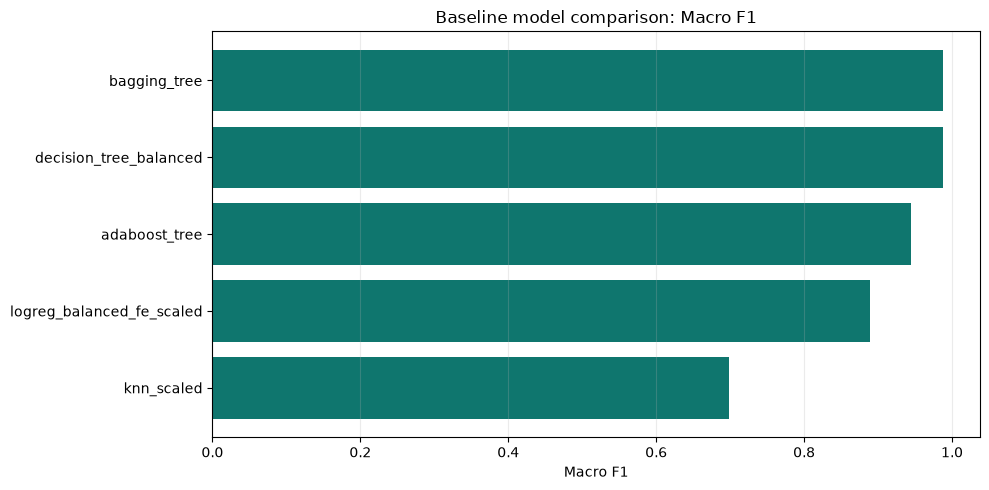

In [18]:
display(baseline_results.sort_values("f1_macro_mean", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
base_plot = baseline_results.sort_values("f1_macro_mean")
ax.barh(base_plot["model_name"], base_plot["f1_macro_mean"], color="#0f766e")
ax.set_title("Baseline model comparison: Macro F1")
ax.set_xlabel("Macro F1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة تجارب النماذج البسيطة

النماذج البسيطة خدمت كخط أساس للمقارنة. أفضلها كان Bagging وDecision Tree، لكن الـ ensemble النهائي بقي أعلى منها بقيمة `OOF Macro F1 ≈ 0.9926`. لذلك احتفظنا بهذه التجارب كتفسير لمسار الاختيار، بينما استخدمنا ensemble كحل نهائي لأنه أعطى أفضل تحقق داخلي.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 11. فحص ثبات النتائج عبر أكثر من تقسيم

أعدنا تقييم أقوى النماذج باستخدام أكثر من `random_state` في `StratifiedKFold`. هذا الفحص يوضح هل أداء النموذج ثابت أم مرتبط بتقسيم واحد محظوظ.

نتائج الثبات أظهرت أن `lightgbm_original` كان الأعلى كمعدل عبر أكثر من split بقيمة `Macro F1 ≈ 0.9898`، ثم `lightgbm_simple_fe` بقيمة `≈ 0.9872`. أقل قيمة سجلها `lightgbm_original` عبر هذه التقسيمات بقيت `≈ 0.9868`، وهذا يدل على أداء مستقر.

</div>

,model_name,f1_macro_mean_over_seeds,f1_macro_std_over_seeds,f1_macro_min_over_seeds,accuracy_mean_over_seeds,balanced_accuracy_mean_over_seeds
0,lightgbm_original,0.989764,0.003511,0.986767,0.997500,0.993324
1,lightgbm_simple_fe,0.987162,0.001957,0.985121,0.996875,0.994277
2,gradient_boosting_fe,0.985604,0.003897,0.981139,0.996563,0.992278
3,hgb_simple_fe,0.983149,0.004266,0.978246,0.996354,0.985091


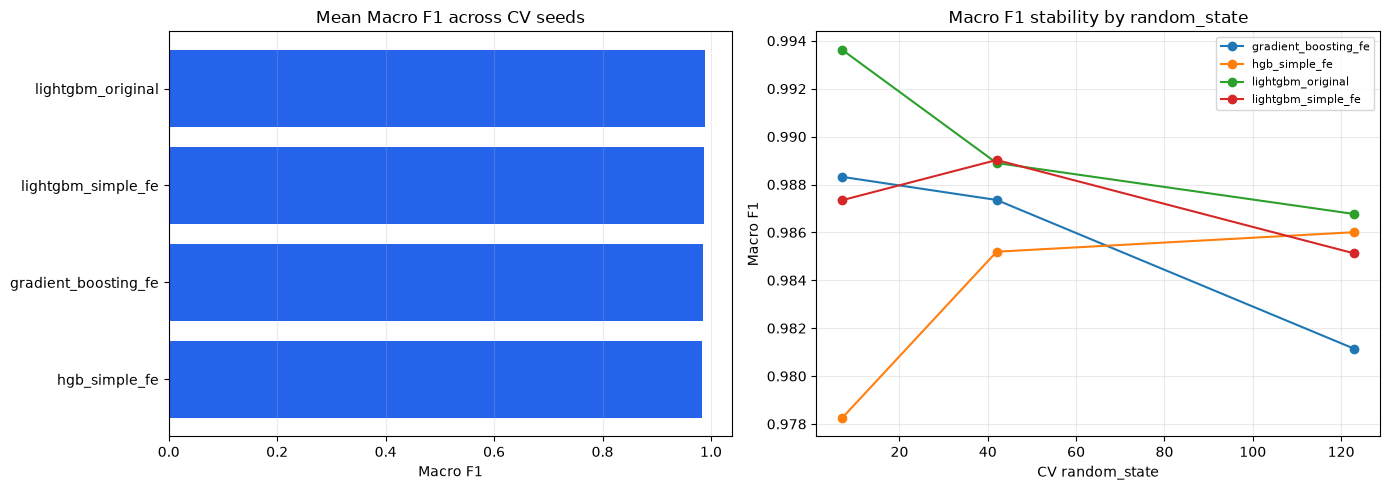

In [19]:
display(robust_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
robust_plot = robust_summary.sort_values("f1_macro_mean_over_seeds")
axes[0].barh(robust_plot["model_name"], robust_plot["f1_macro_mean_over_seeds"], color="#2563eb")
axes[0].set_title("Mean Macro F1 across CV seeds")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

for model_name, group in robust_by_seed.groupby("model_name"):
    axes[1].plot(group["random_state"], group["f1_macro_mean"], marker="o", label=model_name)
axes[1].set_title("Macro F1 stability by random_state")
axes[1].set_xlabel("CV random_state")
axes[1].set_ylabel("Macro F1")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة فحص الثبات

النماذج الأقوى بقيت قوية عبر أكثر من تقسيم. `lightgbm_original` أعطى أفضل متوسط، و`lightgbm_simple_fe` كان الأكثر ثباتا نسبيا بانحراف معياري أقل. هذه النتيجة دعمت استخدام نماذج boosting والأشجار داخل الحل النهائي، وخففت الاعتماد على split واحد أو نتيجة Public واحدة.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 12. رسومات مقارنة الموديلات والـ Ensemble

الرسومات تلخص نتائج الجداول بصريا. الرسم الأول يقارن `Macro F1` للنماذج الأساسية، والرسم الثاني يعرض أوزان الـ ensemble النهائي.

الهدف من هذه الرسومات هو توضيح سبب اختيار الدمج: عدة نماذج قوية كانت متقاربة، والـ ensemble جمع بينها بدل الاعتماد على نموذج واحد فقط.

</div>

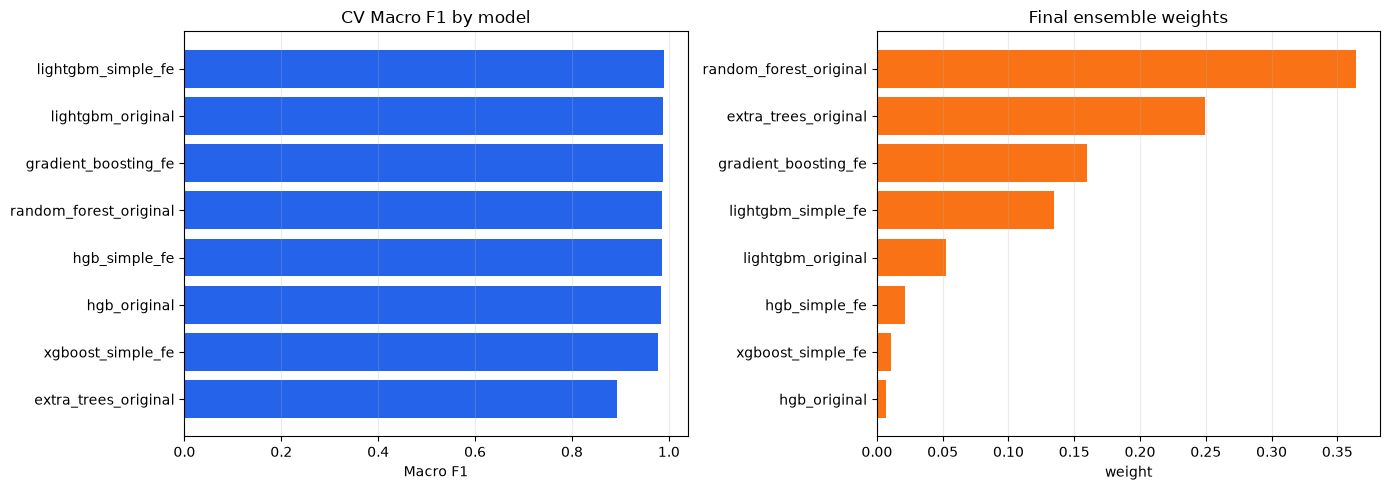

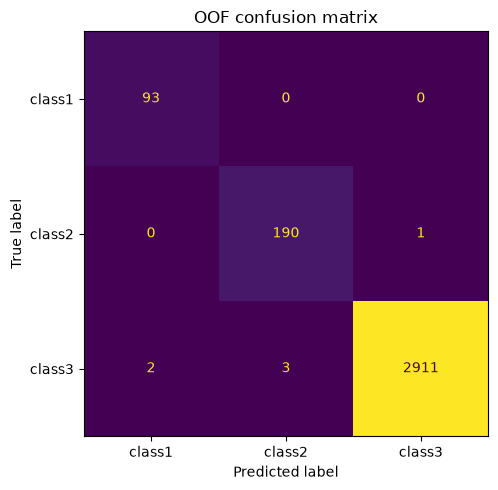

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = cv_results.sort_values("f1_macro_mean")
axes[0].barh(plot_df["model_name"], plot_df["f1_macro_mean"], color="#2563eb")
axes[0].set_title("CV Macro F1 by model")
axes[0].set_xlabel("Macro F1")
axes[0].grid(axis="x", alpha=0.25)

weights_df = pd.DataFrame(list(ensemble_info["weights"].items()), columns=["model", "weight"]).sort_values("weight")
axes[1].barh(weights_df["model"], weights_df["weight"], color="#f97316")
axes[1].set_title("Final ensemble weights")
axes[1].set_xlabel("weight")
axes[1].grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_df.values, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("OOF confusion matrix")
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة الرسومات

الرسم الخاص بالموديلات يبين أن LightGBM بنسختيه كان في المقدمة، وأن Gradient Boosting وRandom Forest قريبان منهما. الرسم الخاص بالأوزان يبين أن الـ ensemble لم يعتمد على نموذج واحد فقط؛ أكبر وزن ذهب إلى `random_forest_original` ثم `extra_trees_original` و`gradient_boosting_fe` مع مساهمة من LightGBM.

هذه الأوزان تعكس أن اختيار الـ ensemble مبني على احتمالات out-of-fold، وليس على ترتيب النماذج منفردة فقط. الدمج النهائي رفع `Macro F1` إلى `≈ 0.9926`.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 13. فحص ملف الرفع

بعد توليد `submission.csv` فحصنا أن الملف مطابق لصيغة الرفع: عمود `ID` وعمود `target` فقط، وعدد الصفوف 3200، وترتيب الـ IDs مطابق لـ `sample_submission.csv`، ولا توجد أي قيم مفقودة في التنبؤات.

هذا الفحص يمنع أخطاء شكلية قد تسبب رفض الملف حتى عندما يكون النموذج صحيحا.

</div>

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


target
class1      81
class2     188
class3    2931
Name: count, dtype: int64

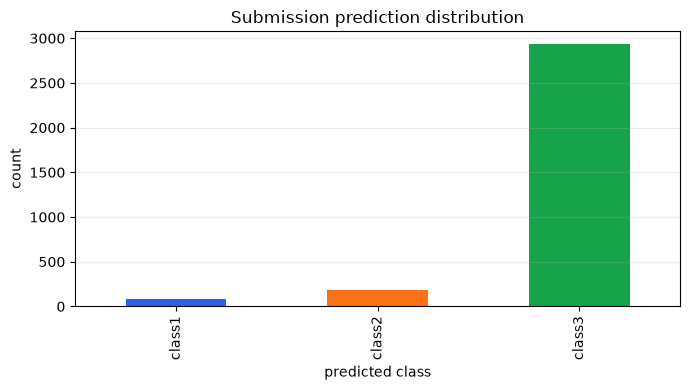

In [21]:
assert list(submission.columns) == [ID_COL, TARGET_COL]
assert submission[ID_COL].tolist() == sample_submission[ID_COL].tolist()
assert submission[TARGET_COL].notna().all()
assert set(submission[TARGET_COL].unique()).issubset(set(class_names))

display(submission.head())
display(submission[TARGET_COL].value_counts().sort_index().rename("count"))

fig, ax = plt.subplots(figsize=(7, 4))
submission[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#2563eb", "#f97316", "#16a34a"])
ax.set_title("Submission prediction distribution")
ax.set_xlabel("predicted class")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

### نتيجة فحص ملف الرفع

ملف `submission.csv` جاهز للرفع. التنبؤات ناتجة بالكامل من النماذج المدربة على `train_data.csv`، ولم يتم تعديل الصفوف يدويا أو استخدام أي labels من الاختبار.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 14. التعامل مع Public و Private

نتائج Public leaderboard قد لا تعكس النتيجة النهائية بالكامل، لأن جزءا من الاختبار يبقى Private. لذلك لم نعتمد على رفع واحد لتحديد جودة النموذج.

القرار النهائي بني على تحقق داخلي متعدد الجوانب: `StratifiedKFold`, `Macro F1`, مقارنة نماذج بسيطة وقوية، وفحص ثبات عبر أكثر من random state. نتيجة Public استخدمت كإشارة إضافية فقط.

</div>

<div dir="rtl" style="text-align:right; font-family: Tahoma, Arial, sans-serif; line-height:1.8;">

## 15. MLflow و DVC في المشروع

استخدمنا MLflow لتسجيل التجارب والمقاييس: اسم النموذج، إعدادات التقييم، Accuracy، Balanced Accuracy، وMacro F1. كما سجلنا تجربة الـ ensemble النهائي مع الأوزان والمخرجات.

واستخدمنا DVC لتتبع ملفات الداتا بدون رفع ملفات CSV الخام إلى GitHub. ملفات `.dvc` الصغيرة موجودة في المستودع، أما الداتا نفسها فمخزنة في Google Drive remote. بهذه الطريقة يبقى المشروع قابلا للتشغيل والمراجعة بدون تضخيم GitHub بملفات البيانات.

</div>